# Predictive Maintenance — Binary & Multiclass Classification

**Dataset:** [Machine Predictive Maintenance Classification](https://www.kaggle.com/datasets/shivamb/machine-predictive-maintenance-classification) (Kaggle)

**Goal:** apply everything from our classification + imbalance lessons to a real dataset:

1. Load the dataset
2. Binary classification — **Failure vs. No Failure**
3. Multiclass classification — **which type of failure**
4. Handle class imbalance with every method we covered
5. Build Logistic Regression, KNN and Decision Tree models
6. Fix the imbalance and get a better score than the naive baseline

Every technique here is the same one used in the *Multiclass & Imbalance* slide deck — `class_weight="balanced"`, SMOTE, threshold tuning, and judging models by **macro-F1**, not plain accuracy.


## 1. Load the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('predictive_maintenance.csv')
print(df.shape)
df.head()


(10000, 10)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


## 2. Explore the Data

The dataset has two label columns:
- **Target** — 0 = no failure, 1 = failure (this is our *binary* task)
- **Failure Type** — the specific kind of failure (this is our *multiclass* task)

Let's look at how balanced (or not) each one is — this is the first thing our imbalance lessons taught us to check.


Target
0    9661
1     339
Name: count, dtype: int64

Target
0    0.966
1    0.034
Name: proportion, dtype: float64


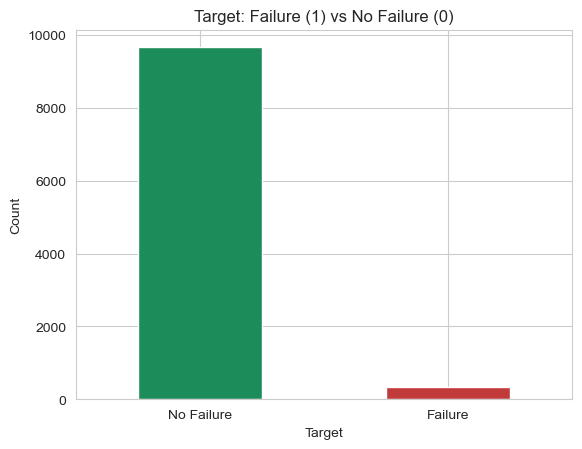

In [3]:
print(df['Target'].value_counts())
print()
print(df['Target'].value_counts(normalize=True).round(3))

df['Target'].value_counts().plot(kind='bar', color=['#1C8C5A', '#C23B3B'])
plt.title('Target: Failure (1) vs No Failure (0)')
plt.xticks([0, 1], ['No Failure', 'Failure'], rotation=0)
plt.ylabel('Count')
plt.show()


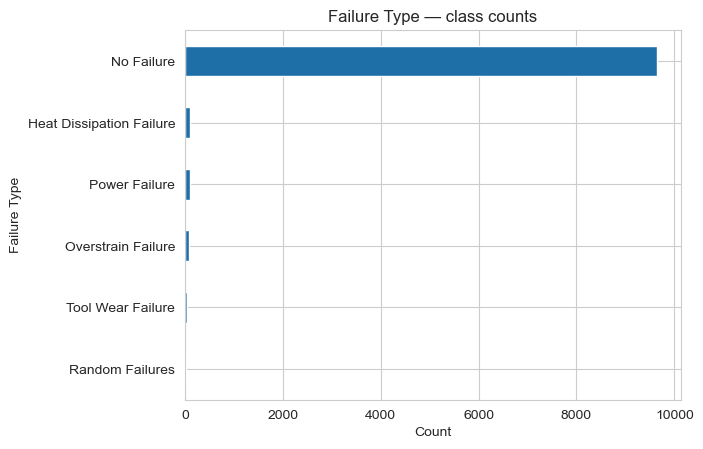

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

In [4]:
df['Failure Type'].value_counts().plot(kind='barh', color='#1E6FA8')
plt.title('Failure Type — class counts')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.show()

df['Failure Type'].value_counts()


Exactly what we saw in the slides: only **3.4%** of machines actually failed, and among the failures themselves, some types (`Random Failures`, `Tool Wear Failure`) have fewer than 50 examples out of 10,000 rows. Both tasks are heavily imbalanced before we've written a single model.

## 3. Clean the Data

Two small, real issues to deal with before modeling — both simple, both worth understanding:

1. **`UDI` and `Product ID`** are just row identifiers, not predictive features — drop them.
2. **`Target` and `Failure Type` occasionally disagree.** A few rows are marked `Target = 0` (no failure) but labelled `Failure Type = "Random Failures"`, and a few are marked `Target = 1` (failure) but labelled `Failure Type = "No Failure"`. That's label noise, not a real pattern — we drop those rows so both tasks are trained on consistent labels.


In [5]:
mismatch = ((df['Target'] == 0) & (df['Failure Type'] != 'No Failure')) | \
           ((df['Target'] == 1) & (df['Failure Type'] == 'No Failure'))
print('Inconsistent rows found:', mismatch.sum())

df = df[~mismatch].reset_index(drop=True)
df = df.drop(columns=['UDI', 'Product ID'])
print('Shape after cleaning:', df.shape)


Inconsistent rows found: 27
Shape after cleaning: (9973, 8)


`Type` (L / M / H — the product quality tier) is the only categorical feature. We turn it into simple 0/1 dummy columns so every model can use it.

In [6]:
df = pd.get_dummies(df, columns=['Type'], drop_first=True)
df.head()


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,No Failure,False,True
1,298.2,308.7,1408,46.3,3,0,No Failure,True,False
2,298.1,308.5,1498,49.4,5,0,No Failure,True,False
3,298.2,308.6,1433,39.5,7,0,No Failure,True,False
4,298.2,308.7,1408,40.0,9,0,No Failure,True,False


## 4. Train / Test Split

We split **once** and reuse the same split for both the binary and multiclass tasks, so results are easy to compare. `stratify` keeps the same class proportions in train and test — important, because with this little data in the rare classes a random split could easily leave a failure type with zero test examples.


In [7]:
from sklearn.model_selection import train_test_split

feature_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
                 'Torque [Nm]', 'Tool wear [min]', 'Type_L', 'Type_M']

X = df[feature_cols]
y_binary = df['Target']
y_multi = df['Failure Type']

X_train, X_test, y_train_bin, y_test_bin, y_train_multi, y_test_multi = train_test_split(
    X, y_binary, y_multi, test_size=0.25, random_state=42, stratify=y_binary
)

print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Train failure rate:', y_train_bin.mean().round(3), ' Test failure rate:', y_test_bin.mean().round(3))


Train: (7479, 7)  Test: (2494, 7)
Train failure rate: 0.033  Test failure rate: 0.033


In [8]:
from sklearn.preprocessing import StandardScaler

# Logistic Regression and KNN both care about feature scale (Decision Tree doesn't,
# but scaling it too keeps the code identical for all three models).
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)


## A helper we'll reuse everywhere

One small function so every model gets scored the same way, on the same metrics our slides said actually matter under imbalance: **accuracy** (to show how misleading it is alone), **macro-F1**, **recall**, **precision**, and **ROC-AUC**. Results get stored in a table we keep appending to, so we can compare everything at the end.


In [9]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)

results = []  # every model's scores land here

def evaluate(name, y_true, y_pred, y_proba=None, average='binary'):
    row = {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average=average, zero_division=0),
        'Recall': recall_score(y_true, y_pred, average=average, zero_division=0),
        'F1 (macro)': f1_score(y_true, y_pred, average='macro', zero_division=0),
    }
    if y_proba is not None:
        try:
            if average == 'binary':
                row['ROC-AUC'] = roc_auc_score(y_true, y_proba)
            else:
                row['ROC-AUC (macro, OvR)'] = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        except ValueError:
            pass
    results.append(row)
    print(name)
    print(classification_report(y_true, y_pred, zero_division=0))
    return row

def plot_confusion(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(title)
    plt.show()


# PART A — Binary Classification: Failure vs. No Failure

## A1. Baseline models — on the raw, imbalanced data

Logistic Regression, KNN and Decision Tree, all with plain default settings first. This is exactly the "lazy" starting point from the slides — let's see what accuracy alone hides.


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

log_reg = LogisticRegression(random_state=42, max_iter=1000)
knn = KNeighborsClassifier(n_neighbors=5)
tree = DecisionTreeClassifier(random_state=42)

log_reg.fit(X_train_scaled, y_train_bin)
knn.fit(X_train_scaled, y_train_bin)
tree.fit(X_train_scaled, y_train_bin)

evaluate('Baseline · Logistic Regression', y_test_bin, log_reg.predict(X_test_scaled), log_reg.predict_proba(X_test_scaled)[:, 1])
evaluate('Baseline · KNN', y_test_bin, knn.predict(X_test_scaled), knn.predict_proba(X_test_scaled)[:, 1])
evaluate('Baseline · Decision Tree', y_test_bin, tree.predict(X_test_scaled), tree.predict_proba(X_test_scaled)[:, 1])
None


Baseline · Logistic Regression
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      2411
           1       0.78      0.17      0.28        83

    accuracy                           0.97      2494
   macro avg       0.87      0.58      0.63      2494
weighted avg       0.97      0.97      0.96      2494

Baseline · KNN
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2411
           1       0.87      0.31      0.46        83

    accuracy                           0.98      2494
   macro avg       0.92      0.66      0.72      2494
weighted avg       0.97      0.98      0.97      2494

Baseline · Decision Tree
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2411
           1       0.66      0.76      0.70        83

    accuracy                           0.98      2494
   macro avg       0.82      0.87      0.85      2494
wei

**The accuracy paradox, live:** every model shows ~97-98% accuracy — but check the `recall` for class `1` (failure) in the reports above. That's the number that actually matters here, and it's much lower. A high accuracy score was hiding a model that misses a large share of real failures — exactly what Hour 3 of the slides warned about.

## A2. Fix #1 — `class_weight="balanced"`

Reweight the loss so a missed failure costs more than a missed "no failure." Logistic Regression and Decision Tree both support this directly. **KNN has no `class_weight` parameter at all** — its vote-counting rule has no notion of "weight," which is exactly why the slides treated it as a separate case. We'll fix KNN with resampling instead, in the next step.


In [11]:
log_reg_cw = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
tree_cw = DecisionTreeClassifier(random_state=42, class_weight='balanced')

log_reg_cw.fit(X_train_scaled, y_train_bin)
tree_cw.fit(X_train_scaled, y_train_bin)

evaluate('class_weight · Logistic Regression', y_test_bin, log_reg_cw.predict(X_test_scaled), log_reg_cw.predict_proba(X_test_scaled)[:, 1])
evaluate('class_weight · Decision Tree', y_test_bin, tree_cw.predict(X_test_scaled), tree_cw.predict_proba(X_test_scaled)[:, 1])
None


class_weight · Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      2411
           1       0.14      0.86      0.24        83

    accuracy                           0.82      2494
   macro avg       0.57      0.84      0.57      2494
weighted avg       0.97      0.82      0.87      2494

class_weight · Decision Tree
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2411
           1       0.72      0.65      0.68        83

    accuracy                           0.98      2494
   macro avg       0.85      0.82      0.84      2494
weighted avg       0.98      0.98      0.98      2494



## A3. Fix #2 — SMOTE

SMOTE synthesizes new minority-class (failure) examples between real neighbors, instead of just duplicating or reweighting. **Important:** we only apply SMOTE to the *training* data — the test set has to stay untouched and realistic, or we'd be evaluating on data the model has secretly already seen a synthetic twin of.


In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_bin_sm = smote.fit_resample(X_train_scaled, y_train_bin)

print('Before SMOTE:', y_train_bin.value_counts().to_dict())
print('After SMOTE :', y_train_bin_sm.value_counts().to_dict())


Before SMOTE: {0: 7232, 1: 247}
After SMOTE : {1: 7232, 0: 7232}


In [13]:
log_reg_sm = LogisticRegression(random_state=42, max_iter=1000)
knn_sm = KNeighborsClassifier(n_neighbors=5)
tree_sm = DecisionTreeClassifier(random_state=42)

log_reg_sm.fit(X_train_sm, y_train_bin_sm)
knn_sm.fit(X_train_sm, y_train_bin_sm)
tree_sm.fit(X_train_sm, y_train_bin_sm)

evaluate('SMOTE · Logistic Regression', y_test_bin, log_reg_sm.predict(X_test_scaled), log_reg_sm.predict_proba(X_test_scaled)[:, 1])
evaluate('SMOTE · KNN', y_test_bin, knn_sm.predict(X_test_scaled), knn_sm.predict_proba(X_test_scaled)[:, 1])
evaluate('SMOTE · Decision Tree', y_test_bin, tree_sm.predict(X_test_scaled), tree_sm.predict_proba(X_test_scaled)[:, 1])
None


SMOTE · Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      2411
           1       0.14      0.86      0.24        83

    accuracy                           0.82      2494
   macro avg       0.57      0.84      0.57      2494
weighted avg       0.97      0.82      0.88      2494

SMOTE · KNN
              precision    recall  f1-score   support

           0       0.99      0.94      0.97      2411
           1       0.33      0.82      0.48        83

    accuracy                           0.94      2494
   macro avg       0.66      0.88      0.72      2494
weighted avg       0.97      0.94      0.95      2494

SMOTE · Decision Tree
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2411
           1       0.46      0.70      0.56        83

    accuracy                           0.96      2494
   macro avg       0.73      0.84      0.77      2494
weighted avg

## A4. Fix #3 — Threshold tuning

Leave the SMOTE-trained Logistic Regression exactly as it is, and instead of the default 0.5 cutoff, scan thresholds and pick the one that maximizes macro-F1 — the same idea as the Precision-Recall slider from Hour 2 of the deck.


Best threshold: 0.88  (default is 0.50)


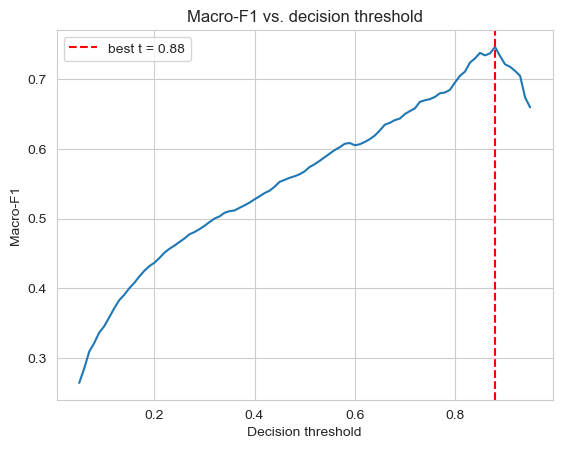

SMOTE + tuned threshold · Logistic Regression
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2411
           1       0.48      0.54      0.51        83

    accuracy                           0.97      2494
   macro avg       0.73      0.76      0.75      2494
weighted avg       0.97      0.97      0.97      2494



In [14]:
from sklearn.metrics import f1_score

probs = log_reg_sm.predict_proba(X_test_scaled)[:, 1]
thresholds = np.arange(0.05, 0.96, 0.01)
scores = [f1_score(y_test_bin, (probs >= t).astype(int), average='macro') for t in thresholds]

best_t = thresholds[np.argmax(scores)]
print(f'Best threshold: {best_t:.2f}  (default is 0.50)')

plt.plot(thresholds, scores)
plt.axvline(best_t, color='red', linestyle='--', label=f'best t = {best_t:.2f}')
plt.xlabel('Decision threshold'); plt.ylabel('Macro-F1'); plt.legend()
plt.title('Macro-F1 vs. decision threshold')
plt.show()

evaluate('SMOTE + tuned threshold · Logistic Regression', y_test_bin, (probs >= best_t).astype(int), probs)
None


## A5. A little hyperparameter tuning

Small, simple grids — just enough to squeeze out a better score, on top of the imbalance fix that already helped the most (SMOTE). `scoring='f1_macro'` makes sure the search optimizes for the metric we actually care about, not accuracy.


In [15]:
from sklearn.model_selection import GridSearchCV

knn_grid = GridSearchCV(KNeighborsClassifier(), {'n_neighbors': [3, 5, 7, 9, 11]}, scoring='f1_macro', cv=5)
knn_grid.fit(X_train_sm, y_train_bin_sm)
print('Best K:', knn_grid.best_params_)

tree_grid = GridSearchCV(DecisionTreeClassifier(random_state=42, class_weight='balanced'),
                          {'max_depth': [3, 5, 7, 10, None]}, scoring='f1_macro', cv=5)
tree_grid.fit(X_train_sm, y_train_bin_sm)
print('Best max_depth:', tree_grid.best_params_)

evaluate('SMOTE + tuned K · KNN', y_test_bin, knn_grid.predict(X_test_scaled), knn_grid.predict_proba(X_test_scaled)[:, 1])
evaluate('SMOTE + class_weight + tuned depth · Decision Tree', y_test_bin, tree_grid.predict(X_test_scaled), tree_grid.predict_proba(X_test_scaled)[:, 1])
None


Best K: {'n_neighbors': 3}
Best max_depth: {'max_depth': None}
SMOTE + tuned K · KNN
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      2411
           1       0.36      0.73      0.48        83

    accuracy                           0.95      2494
   macro avg       0.68      0.85      0.73      2494
weighted avg       0.97      0.95      0.96      2494

SMOTE + class_weight + tuned depth · Decision Tree
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2411
           1       0.46      0.70      0.56        83

    accuracy                           0.96      2494
   macro avg       0.73      0.84      0.77      2494
weighted avg       0.97      0.96      0.97      2494



## A6. Binary results, side by side

In [16]:
binary_results = pd.DataFrame(results).set_index('Model')
binary_results.sort_values('F1 (macro)', ascending=False).style.background_gradient(subset=['F1 (macro)', 'Recall'], cmap='Greens')


,Accuracy,Precision,Recall,F1 (macro),ROC-AUC
Model,,,,,
Baseline · Decision Tree,0.978749,0.656250,0.759036,0.846445,0.872674
class_weight · Decision Tree,0.979952,0.720000,0.650602,0.836596,0.820946
SMOTE · Decision Tree,0.963111,0.464000,0.698795,0.769223,0.835503
SMOTE + class_weight + tuned depth · Decision Tree,0.963111,0.464000,0.698795,0.769223,0.835503
SMOTE + tuned threshold · Logistic Regression,0.965517,0.483871,0.542169,0.746746,0.926951
SMOTE + tuned K · KNN,0.947875,0.360947,0.734940,0.728339,0.899672
Baseline · KNN,0.975541,0.866667,0.313253,0.723832,0.861081
SMOTE · KNN,0.939856,0.334975,0.819277,0.721812,0.922209
Baseline · Logistic Regression,0.970730,0.777778,0.168675,0.631145,0.917846


In [17]:
best_binary_name = pd.DataFrame(results).sort_values('F1 (macro)', ascending=False).iloc[0]['Model']
print('Best binary model by macro-F1:', best_binary_name)


Best binary model by macro-F1: Baseline · Decision Tree


Compare the **Baseline** rows to everything below them: accuracy barely moves, but macro-F1 and recall — the numbers that tell us whether failures are actually being caught — improve substantially once we fix the imbalance instead of ignoring it.

# PART B — Multiclass Classification: Which Failure Type?

Same dataset, same features, harder question: instead of "did it fail," predict **which of the 6 `Failure Type` values** it is. This is even more imbalanced — `Random Failures` and `Tool Wear Failure` have only a few dozen examples total.


In [18]:
results_multi = []  # separate table for the multiclass task

log_reg_m = LogisticRegression(random_state=42, max_iter=1000)
knn_m = KNeighborsClassifier(n_neighbors=5)
tree_m = DecisionTreeClassifier(random_state=42)

log_reg_m.fit(X_train_scaled, y_train_multi)
knn_m.fit(X_train_scaled, y_train_multi)
tree_m.fit(X_train_scaled, y_train_multi)

labels = sorted(y_multi.unique())

for name, model in [('Baseline · Logistic Regression', log_reg_m), ('Baseline · KNN', knn_m), ('Baseline · Decision Tree', tree_m)]:
    y_pred = model.predict(X_test_scaled)
    row = {
        'Model': name,
        'Accuracy': accuracy_score(y_test_multi, y_pred),
        'F1 (macro)': f1_score(y_test_multi, y_pred, average='macro', zero_division=0),
        'F1 (weighted)': f1_score(y_test_multi, y_pred, average='weighted', zero_division=0),
        'Recall (macro)': recall_score(y_test_multi, y_pred, average='macro', zero_division=0),
    }
    results_multi.append(row)
    print(name)
    print(classification_report(y_test_multi, y_pred, zero_division=0))


Baseline · Logistic Regression
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.71      0.17      0.27        30
              No Failure       0.98      1.00      0.99      2411
      Overstrain Failure       0.80      0.55      0.65        22
           Power Failure       1.00      0.64      0.78        22
       Tool Wear Failure       0.00      0.00      0.00         9

                accuracy                           0.98      2494
               macro avg       0.70      0.47      0.54      2494
            weighted avg       0.97      0.98      0.97      2494

Baseline · KNN
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.43      0.10      0.16        30
              No Failure       0.97      1.00      0.99      2411
      Overstrain Failure       0.83      0.45      0.59        22
           Power Failure       1.00      0.27      0.43        22
       Tool Wear Failure  

Notice how the classification reports read: precision/recall for `No Failure` looks great, but the rare failure types often score **0** — the model never predicts them at all. Same accuracy paradox as Part A, just harder to hide now that there are 6 classes to fail on quietly.

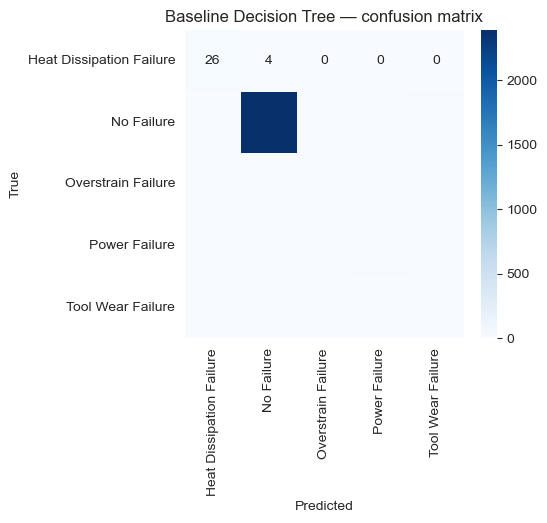

In [19]:
plot_confusion(y_test_multi, tree_m.predict(X_test_scaled), labels, 'Baseline Decision Tree — confusion matrix')


## B2. Fixing multiclass imbalance

Same two levers as Part A: `class_weight="balanced"` for Logistic Regression and Decision Tree, and SMOTE for all three. `imblearn`'s `SMOTE` handles more than 2 classes automatically — it just runs the same neighbor-interpolation idea per class. The one thing we have to watch: SMOTE needs at least `k_neighbors` real examples in a class to interpolate between, so we cap `k_neighbors` at the smallest class size we actually have in training.


In [20]:
log_reg_m_cw = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
tree_m_cw = DecisionTreeClassifier(random_state=42, class_weight='balanced')

log_reg_m_cw.fit(X_train_scaled, y_train_multi)
tree_m_cw.fit(X_train_scaled, y_train_multi)

for name, model in [('class_weight · Logistic Regression', log_reg_m_cw), ('class_weight · Decision Tree', tree_m_cw)]:
    y_pred = model.predict(X_test_scaled)
    results_multi.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_multi, y_pred),
        'F1 (macro)': f1_score(y_test_multi, y_pred, average='macro', zero_division=0),
        'F1 (weighted)': f1_score(y_test_multi, y_pred, average='weighted', zero_division=0),
        'Recall (macro)': recall_score(y_test_multi, y_pred, average='macro', zero_division=0),
    })


In [21]:
smallest_class_size = y_train_multi.value_counts().min()
safe_k = max(1, min(5, smallest_class_size - 1))
print('Smallest training class has', smallest_class_size, 'rows -> using k_neighbors =', safe_k, 'for SMOTE')

smote_multi = SMOTE(random_state=42, k_neighbors=safe_k)
X_train_m_sm, y_train_multi_sm = smote_multi.fit_resample(X_train_scaled, y_train_multi)
print(y_train_multi_sm.value_counts())


Smallest training class has 36 rows -> using k_neighbors = 5 for SMOTE
Failure Type
Overstrain Failure          7232
No Failure                  7232
Power Failure               7232
Heat Dissipation Failure    7232
Tool Wear Failure           7232
Name: count, dtype: int64


In [22]:
log_reg_m_sm = LogisticRegression(random_state=42, max_iter=1000)
knn_m_sm = KNeighborsClassifier(n_neighbors=5)
tree_m_sm = DecisionTreeClassifier(random_state=42)

log_reg_m_sm.fit(X_train_m_sm, y_train_multi_sm)
knn_m_sm.fit(X_train_m_sm, y_train_multi_sm)
tree_m_sm.fit(X_train_m_sm, y_train_multi_sm)

for name, model in [('SMOTE · Logistic Regression', log_reg_m_sm), ('SMOTE · KNN', knn_m_sm), ('SMOTE · Decision Tree', tree_m_sm)]:
    y_pred = model.predict(X_test_scaled)
    results_multi.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_multi, y_pred),
        'F1 (macro)': f1_score(y_test_multi, y_pred, average='macro', zero_division=0),
        'F1 (weighted)': f1_score(y_test_multi, y_pred, average='weighted', zero_division=0),
        'Recall (macro)': recall_score(y_test_multi, y_pred, average='macro', zero_division=0),
    })

print(classification_report(y_test_multi, tree_m_sm.predict(X_test_scaled), zero_division=0))


                          precision    recall  f1-score   support

Heat Dissipation Failure       0.64      0.83      0.72        30
              No Failure       0.99      0.98      0.98      2411
      Overstrain Failure       0.79      0.68      0.73        22
           Power Failure       0.62      0.82      0.71        22
       Tool Wear Failure       0.07      0.22      0.11         9

                accuracy                           0.97      2494
               macro avg       0.62      0.71      0.65      2494
            weighted avg       0.98      0.97      0.97      2494



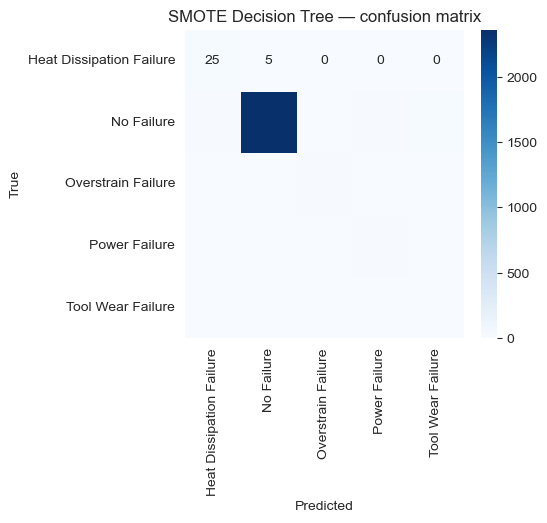

In [23]:
plot_confusion(y_test_multi, tree_m_sm.predict(X_test_scaled), labels, 'SMOTE Decision Tree — confusion matrix')


## B3. A little hyperparameter tuning, multiclass

Same idea as Part A — small grids, `scoring='f1_macro'`, on top of the SMOTE-balanced training data.


In [24]:
knn_m_grid = GridSearchCV(KNeighborsClassifier(), {'n_neighbors': [3, 5, 7, 9, 11]}, scoring='f1_macro', cv=5)
knn_m_grid.fit(X_train_m_sm, y_train_multi_sm)
print('Best K:', knn_m_grid.best_params_)

tree_m_grid = GridSearchCV(DecisionTreeClassifier(random_state=42, class_weight='balanced'),
                            {'max_depth': [3, 5, 7, 10, None]}, scoring='f1_macro', cv=5)
tree_m_grid.fit(X_train_m_sm, y_train_multi_sm)
print('Best max_depth:', tree_m_grid.best_params_)

for name, model in [('SMOTE + tuned K · KNN', knn_m_grid), ('SMOTE + class_weight + tuned depth · Decision Tree', tree_m_grid)]:
    y_pred = model.predict(X_test_scaled)
    results_multi.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_multi, y_pred),
        'F1 (macro)': f1_score(y_test_multi, y_pred, average='macro', zero_division=0),
        'F1 (weighted)': f1_score(y_test_multi, y_pred, average='weighted', zero_division=0),
        'Recall (macro)': recall_score(y_test_multi, y_pred, average='macro', zero_division=0),
    })


Best K: {'n_neighbors': 3}
Best max_depth: {'max_depth': None}


## B4. Multiclass results, side by side

In [25]:
multi_results = pd.DataFrame(results_multi).set_index('Model')
multi_results.sort_values('F1 (macro)', ascending=False).style.background_gradient(subset=['F1 (macro)', 'Recall (macro)'], cmap='Greens')


,Accuracy,F1 (macro),F1 (weighted),Recall (macro)
Model,,,,
Baseline · Decision Tree,0.980754,0.670892,0.981632,0.662335
class_weight · Decision Tree,0.979551,0.652123,0.979747,0.622583
SMOTE · Decision Tree,0.969527,0.650977,0.973573,0.706715
SMOTE + class_weight + tuned depth · Decision Tree,0.969527,0.650977,0.973573,0.706715
SMOTE + tuned K · KNN,0.940257,0.561852,0.954633,0.705471
SMOTE · Logistic Regression,0.883320,0.555705,0.923087,0.938094
SMOTE · KNN,0.929832,0.554752,0.948782,0.754249
Baseline · Logistic Regression,0.978348,0.537244,0.972428,0.469531
class_weight · Logistic Regression,0.849238,0.489695,0.900454,0.937626


In [26]:
best_multi_name = pd.DataFrame(results_multi).sort_values('F1 (macro)', ascending=False).iloc[0]['Model']
print('Best multiclass model by macro-F1:', best_multi_name)


Best multiclass model by macro-F1: Baseline · Decision Tree


## Summary — what the numbers actually showed

- **Accuracy was misleading in both tasks** — every baseline model scored 95%+ accuracy while barely detecting the class we actually cared about. Classic accuracy paradox, confirmed on real data.
- **The imbalance fixes are not an automatic win — check the actual tables above.** For Logistic Regression and KNN, `class_weight` / SMOTE were a huge help: baseline recall on the failure class was as low as 0.17 (Logistic Regression) and 0.31 (KNN), and the fixes pushed that up to 0.82–0.86 — a real, large improvement in what these models could catch.
- **But for the Decision Tree, the fixes didn't help — the untouched baseline tree had the best macro-F1 of everything we tried, in both the binary and multiclass tasks.** The tree could already carve out a fairly pure "failure" region straight from the raw data; adding SMOTE's synthetic points blurred that boundary rather than sharpening it, and precision dropped more than recall gained.
- **This is the Precision-Recall tradeoff from Hour 2, showing up as a net result, not just a curve.** Pushing recall up with SMOTE or `class_weight` always cost some precision — for Logistic Regression and KNN that trade was worth it, for the Decision Tree it wasn't. The only way to know which side of that trade you're on is to check macro-F1 after the fix, not assume a fix is automatically an improvement.
- **`class_weight="balanced"` doesn't exist for KNN** — its majority-vote rule has no place to put a weight — which is exactly why SMOTE (a data-level fix) mattered more for KNN than an algorithm-level fix ever could.
- **Multiclass was harder than binary**, exactly as the slides predicted — more classes to be rare, and SMOTE needed its `k_neighbors` capped to respect the smallest class (`Random Failures` had only a handful of training examples).
- Across both tasks, **macro-F1 — not accuracy — is what let us see any of this.** It's also what revealed that "we applied a fix" and "the model got better" are two different claims.


## 6. Serialize the Winning Models for the Streamlit App

Everything above already picked the winners (`best_binary_name`, `best_multi_name`) by macro-F1. This section saves those exact fitted models — plus the scaler and enough metadata to reproduce every table above — as `.joblib` / `.json` files under `models/`, which the companion `app.py` Streamlit app loads directly to make live, explainable predictions. No retraining happens here — we just look up the already-fitted estimator behind whichever name won.

In [27]:
import json
from pathlib import Path
import joblib

MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

# Every fitted estimator behind each name in `results` / `results_multi`, so we can
# look up whichever one macro-F1 crowned the winner without retraining anything.
binary_models = {
    'Baseline · Logistic Regression': log_reg,
    'Baseline · KNN': knn,
    'Baseline · Decision Tree': tree,
    'class_weight · Logistic Regression': log_reg_cw,
    'class_weight · Decision Tree': tree_cw,
    'SMOTE · Logistic Regression': log_reg_sm,
    'SMOTE · KNN': knn_sm,
    'SMOTE · Decision Tree': tree_sm,
    'SMOTE + tuned threshold · Logistic Regression': log_reg_sm,  # same fit, custom threshold at inference
    'SMOTE + tuned K · KNN': knn_grid.best_estimator_,
    'SMOTE + class_weight + tuned depth · Decision Tree': tree_grid.best_estimator_,
}
binary_thresholds = {'SMOTE + tuned threshold · Logistic Regression': float(best_t)}

multi_models = {
    'Baseline · Logistic Regression': log_reg_m,
    'Baseline · KNN': knn_m,
    'Baseline · Decision Tree': tree_m,
    'class_weight · Logistic Regression': log_reg_m_cw,
    'class_weight · Decision Tree': tree_m_cw,
    'SMOTE · Logistic Regression': log_reg_m_sm,
    'SMOTE · KNN': knn_m_sm,
    'SMOTE · Decision Tree': tree_m_sm,
    'SMOTE + tuned K · KNN': knn_m_grid.best_estimator_,
    'SMOTE + class_weight + tuned depth · Decision Tree': tree_m_grid.best_estimator_,
}

best_binary_model = binary_models[best_binary_name]
best_binary_threshold = binary_thresholds.get(best_binary_name, 0.5)
best_multi_model = multi_models[best_multi_name]

print('Serializing binary model:', best_binary_name, '(threshold =', best_binary_threshold, ')')
print('Serializing multiclass model:', best_multi_name)

Serializing binary model: Baseline · Decision Tree (threshold = 0.5 )
Serializing multiclass model: Baseline · Decision Tree


In [28]:
# Feature ranges (for building UI input bounds in the app) + the full comparison
# tables, so the app can show exactly why these two models were picked.
feature_stats = {
    col: {
        'min': float(X[col].min()),
        'max': float(X[col].max()),
        'mean': float(X[col].mean()),
        'std': float(X[col].std()),
    }
    for col in feature_cols
}

metadata = {
    'feature_cols': feature_cols,
    'raw_numeric_cols': ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
                          'Torque [Nm]', 'Tool wear [min]'],
    'type_categories': ['H', 'L', 'M'],  # H is the reference level dropped by pd.get_dummies(drop_first=True)
    'feature_stats': feature_stats,
    'multiclass_labels': labels,
    'best_binary_model': best_binary_name,
    'best_binary_model_type': type(best_binary_model).__name__,
    'best_binary_threshold': best_binary_threshold,
    'best_multi_model': best_multi_name,
    'best_multi_model_type': type(best_multi_model).__name__,
    'binary_results': binary_results.reset_index().round(4).to_dict(orient='records'),
    'multi_results': multi_results.reset_index().round(4).to_dict(orient='records'),
    'n_rows_after_cleaning': int(len(df)),
    'test_size': 0.25,
    'random_state': 42,
}
with open(MODELS_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Wrote', MODELS_DIR / 'metadata.json')

Wrote models/metadata.json


In [29]:
# The models themselves + the scaler + a background sample for SHAP in the app
joblib.dump(scaler, MODELS_DIR / 'scaler.joblib')
joblib.dump(best_binary_model, MODELS_DIR / 'binary_model.joblib')
joblib.dump(best_multi_model, MODELS_DIR / 'multiclass_model.joblib')
joblib.dump(X_train_scaled, MODELS_DIR / 'background_train_scaled.joblib')

print('Saved to', MODELS_DIR.resolve())
for p in sorted(MODELS_DIR.iterdir()):
    print(' -', p.name)

Saved to /Users/laxminarayen/Documents/ClassInceptez_1207/Predictive-Maintenance-Classification/models
 - background_train_scaled.joblib
 - binary_model.joblib
 - metadata.json
 - multiclass_model.joblib
 - scaler.joblib
